## The best Deep Artificial Nueral Network for Titanic Classification  

In [ ]:
# importing important packages

import pandas as pd # data frame
import matplotlib.pyplot as plt # ploting
import seaborn as sns # advance visualization


from sklearn.preprocessing import LabelEncoder # Categorical encoder
from sklearn.preprocessing import StandardScaler # Scaler

from sklearn.model_selection  import train_test_split
from imblearn.over_sampling import RandomOverSampler

In [ ]:
# Louding Titanic Train and test datasets
df = pd.read_csv("/content/train.csv")
test_set = pd.read_csv("/content/test.csv")

In [ ]:
df.head() # Print first 5 rows of df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info() # shows important information datatypes, null values ...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB




*  Since Name and Passenger are not that meaningful features it is better to drop them

---
*   Ticket could have been a very good feature, but the huge virution of more that 400 uniqe categories after encoding will disrupt the model learning wither useing label or target encoder, over looking the huge exploding of dimensionality if using one hot encoder. Therefore, the better move is to drop it. the Pclass and Embarked features will cover the lost of this feature

---
*   Cabin also a good feature, but almost all of its instants are null values, using fillna with mean or median is not an ideal move, since it creates artificial data hard to Rely on. the best move is to drop it





In [ ]:
df = df.drop(columns= ['Ticket', 'Name', 'PassengerId', 'Cabin'])
test_set = test_set.drop(columns= ['Ticket', 'Name', 'PassengerId', 'Cabin'])


As I descust the Cabin feature Contains vast samples of null values. therefore, it is Crucial to drop it before running dropna function. **OR most of the data will be lost**

In [ ]:
df = df.dropna()
test_set = test_set.dropna()

In [ ]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,0.404494,2.240169,29.642093,0.514045,0.432584,34.567251
std,0.491139,0.836854,14.492933,0.930692,0.854181,52.938648
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,20.000000,0.000000,0.000000,8.050000
50%,0.000000,2.000000,28.000000,0.000000,0.000000,15.645850
75%,1.000000,3.000000,38.000000,1.000000,1.000000,33.000000
max,1.000000,3.000000,80.000000,5.000000,6.000000,512.329200


In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
# encodeing categorical data to numaric data using label encoder
LE_Sex = LabelEncoder()
LE_Embarked = LabelEncoder()

df['Sex'] = LE_Sex.fit_transform(df['Sex'])
test_set['Sex'] = LE_Sex.transform(test_set['Sex'])

df['Embarked'] = LE_Embarked.fit_transform(df['Embarked'])
test_set['Embarked'] = LE_Embarked.transform(test_set['Embarked'])

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [ ]:
# split features and target

x = df.drop(columns = 'Survived')
y = df['Survived']

 it is important to split the data into train and val sets before
continuing with the rest of the preprocessing *

**To avoid any data leakage**

the test_size and random_state were tuned with the best values which lead to the best generalized model


In [ ]:
x_train, x_val, y_train, y_val = train_test_split( x, y, test_size=0.3, random_state=35,shuffle=True )


In [ ]:
print(y_train.value_counts())
print('_________')

print(y_val.value_counts())

Survived
0    293
1    205
Name: count, dtype: int64
_________
Survived
0    131
1     83
Name: count, dtype: int64


In [ ]:
# OS = RandomOverSampler()
# x_train, y_train = OS.fit_resample(x_train, y_train)
# x_test, y_test = OS.fit_resample(x_test, y_test)

 it is important to always fit_transform the train set , but only transform test and val sets
 *

 and that is why we Train_test_split before scaling


***To avoid any data leakage***



In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
test_set = scaler.transform(test_set)

### DNN Model Training

In [ ]:
import keras
from keras import layers
from keras.optimizers import Adam, SGD, AdamW, Adadelta
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from tensorflow.keras.regularizers import l2, l1

from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report


Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.4691 - loss: 0.7011 
Epoch 1: val_loss improved from inf to 0.67354, saving model to best_model_l1l2.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - binary_accuracy: 0.4882 - loss: 0.6982 - val_binary_accuracy: 0.6121 - val_loss: 0.6735
Epoch 2/150
22/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.6016 - loss: 0.6782 
Epoch 2: val_loss improved from 0.67354 to 0.62047, saving model to best_model_l1l2.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.5964 - loss: 0.6746 - val_binary_accuracy: 0.6121 - val_loss: 0.6205
Epoch 3/150
23/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.5797 - loss: 0.6248 
Epoch 3: val_loss improved from 0.62047 to 0.50093, saving model to best_model_l1l2.weights.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.6191 - loss: 0.6091 - val_binary_accuracy: 0.7944 - val_loss: 0.5009
Epoch 4/150
22/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accu

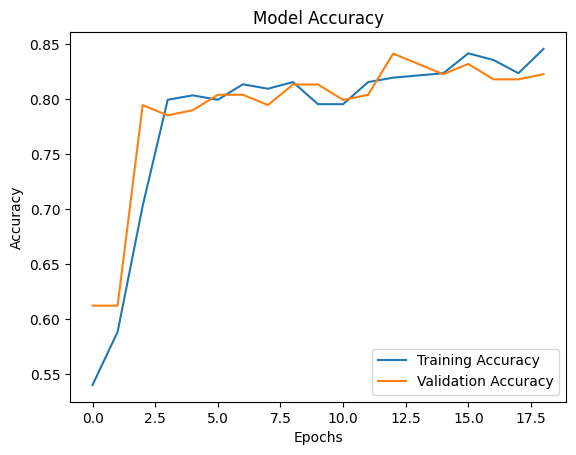

In [ ]:
model = keras.Sequential([

        layers.Dense(40, activation='relu', input_shape=(7,)),
        layers.Dropout(0.2),

        layers.Dense(2, activation='linear'),
        layers.Dense(2, activation='linear'),


        layers.Dense(30, activation='relu'),
        layers.Dropout(0.2),


        layers.Dense(2, activation='linear'),
        layers.Dense(2, activation='linear'),


        layers.Dense(20, activation='relu'),
        layers.Dropout(0.2),



        layers.Dense(2, activation='linear'),

        layers.Dense(1, activation='sigmoid'),
])


model.compile( optimizer = AdamW(learning_rate = 0.0015), loss = BinaryCrossentropy(), metrics=[BinaryAccuracy()])



early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_checkpoint = ModelCheckpoint('best_model_l1l2.weights.h5',
                                   save_best_only=True,
                                   save_weights_only=True,
                                   monitor='val_loss',
                                   mode='min',
                                   verbose=1)



history =  model.fit(x_train, y_train,
                     batch_size =15,
                     epochs = 150,
                     validation_data=(x_val, y_val),
                     callbacks=[early_stopping, model_checkpoint],)



test_loss, test_accuracy = model.evaluate(x_val, y_val)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")




plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
classification_report for testing data: 
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       131
           1       0.78      0.80      0.79        83

    accuracy                           0.83       214
   macro avg       0.82      0.83      0.82       214
weighted avg       0.83      0.83      0.83       214



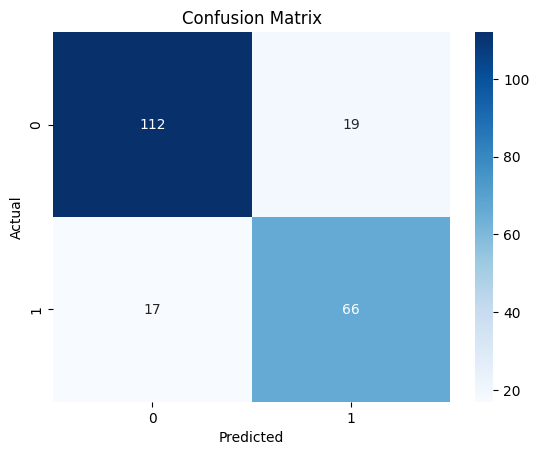

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


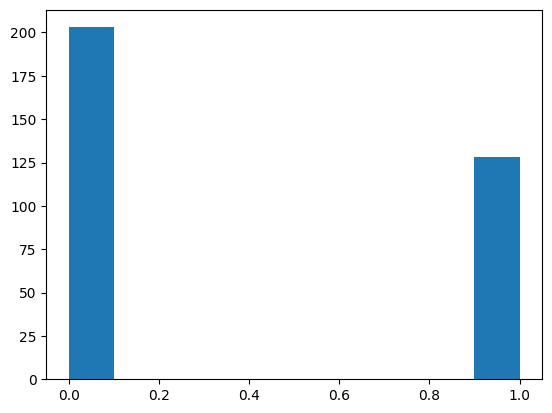

In [ ]:
#_______________________________________________________________________
y_pre = model.predict(x_val)

for i in range(len(y_pre)):
  if y_pre[i] >= 0.5:
    y_pre[i]=1
  else:
    y_pre[i]=0

print("classification_report for testing data: ")
print(classification_report(y_val, y_pre))

sns.heatmap(confusion_matrix(y_val, y_pre), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


#___________________________________________________________

y_pre_test = model.predict(test_set)

for i in range(len(y_pre_test)):
  if y_pre_test[i] >= 0.5:
    y_pre_test[i]=1
  else:
    y_pre_test[i]=0

label =  ['Did not Survive', 'Survived']
plt.hist(y_pre_test)

plt.show()